<a href="https://colab.research.google.com/github/Wancing/Portfolio/blob/main/lisbon-drinking-water-analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import json
import pandas as pd
import folium
from folium.plugins import HeatMap

# Load your GeoJSON
with open('export.geojson', 'r') as f:
    data = json.load(f)

# Extract lat/lon
features = data['features']
coords = []
for feat in features:
    lon, lat = feat['geometry']['coordinates']
    coords.append([lat, lon])  # HeatMap needs [lat, lon]

# Base map (Lisbon center)
m = folium.Map(location=[38.7229, -9.1521], zoom_start=13)

# Add heatmap (red=high density)
HeatMap(coords, radius=20, blur=15, gradient={0.2:'blue', 0.5:'yellow', 1:'red'}).add_to(m)

# Optional: add markers
for i, (lat, lon) in enumerate(coords):
    folium.CircleMarker([lat, lon], radius=3, popup=f'Spot {i+1}').add_to(m)

m.save('lisbon_water_heatmap.html')  # Open in browser
print('Heatmap saved as lisbon_water_heatmap.html')


Heatmap saved as lisbon_water_heatmap.html


In [10]:
!pip install geopandas -q
import geopandas as gpd
import pandas as pd
import json
from shapely.geometry import Point

# STEP 1: Load water spots
with open('export.geojson', 'r') as f:
    data = json.load(f)

water_rows = []
for feat in data['features']:
    props = feat['properties']
    lon, lat = feat['geometry']['coordinates']
    props['lat'] = lat
    props['lon'] = lon
    water_rows.append(props)

df = pd.DataFrame(water_rows)
spots_gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.lon, df.lat), crs="EPSG:4326")
print(f"Water spots loaded: {len(spots_gdf)}")

# STEP 2: Load neighborhood BOUNDARIES (polygons)
freg = gpd.read_file('Limite_Cartografia_6999412068813841003.geojson')
freg = freg.to_crs("EPSG:4326")
print(f"Neighborhoods loaded: {len(freg)}")
print(freg.columns.tolist())

# STEP 3: Spatial join
joined = gpd.sjoin(spots_gdf, freg, how='left', predicate='within')

# STEP 4: Count spots per neighborhood
counts = joined.groupby('NOME').size().reset_index(name='spots')
counts = counts.sort_values('spots', ascending=False)

print("\nSpots per neighborhood:")
print(counts)

counts.to_csv('neighborhood_coverage.csv', index=False)
print("\nSaved: neighborhood_coverage.csv")


Water spots loaded: 159
Neighborhoods loaded: 24
['OBJECTID', 'COD_SIG', 'NOME', 'IDTIPO', 'PERIMETRO', 'AREA_M2', 'FREGUESIAS53', 'GlobalID', 'geometry']

Spots per neighborhood:
                       NOME  spots
5                 Campolide     28
8         Santa Maria Maior     20
1                   Arroios     19
2            Avenidas Novas     19
9             Santo António     17
6                   Estrela     16
7              Misericórdia     16
3                   Benfica      8
4          Campo de Ourique      6
0                   Areeiro      4
10  São Domingos de Benfica      4
11              São Vicente      2

Saved: neighborhood_coverage.csv


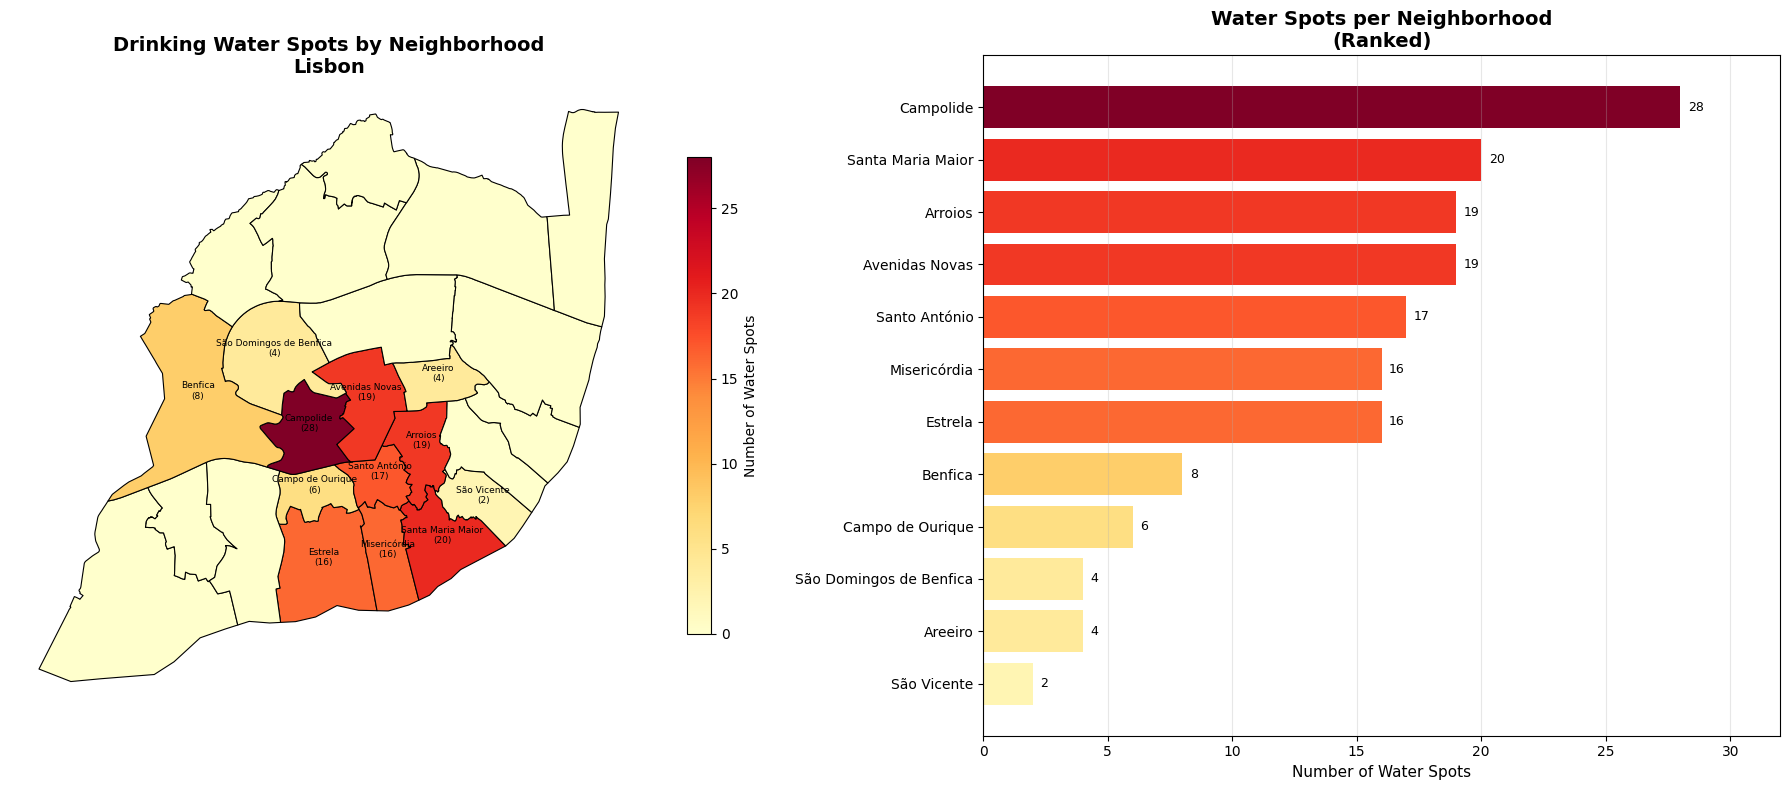

Saved: lisbon_water_map.png


In [11]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import geopandas as gpd
import pandas as pd

# Merge counts back into the geodataframe
freg_merged = freg.merge(counts, on='NOME', how='left')
freg_merged['spots'] = freg_merged['spots'].fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# --- LEFT: Choropleth Map ---
ax1 = axes[0]
freg_merged.plot(
    column='spots',
    cmap='YlOrRd',
    linewidth=0.8,
    edgecolor='black',
    legend=True,
    legend_kwds={'label': 'Number of Water Spots', 'shrink': 0.7},
    ax=ax1,
    missing_kwds={'color': 'lightgrey', 'label': 'No data'}
)
# Add neighborhood labels
for _, row in freg_merged.iterrows():
    if row['spots'] > 0:
        ax1.annotate(
            f"{row['NOME']}\n({int(row['spots'])})",
            xy=(row.geometry.centroid.x, row.geometry.centroid.y),
            ha='center', fontsize=6.5, color='black'
        )
ax1.set_title('Drinking Water Spots by Neighborhood\nLisbon', fontsize=14, fontweight='bold')
ax1.axis('off')

# --- RIGHT: Bar Chart ---
ax2 = axes[1]
sorted_counts = counts.sort_values('spots', ascending=True)
colors = plt.cm.YlOrRd([x / sorted_counts['spots'].max() for x in sorted_counts['spots']])
bars = ax2.barh(sorted_counts['NOME'], sorted_counts['spots'], color=colors)
ax2.set_xlabel('Number of Water Spots', fontsize=11)
ax2.set_title('Water Spots per Neighborhood\n(Ranked)', fontsize=14, fontweight='bold')
for bar, val in zip(bars, sorted_counts['spots']):
    ax2.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             str(val), va='center', fontsize=9)
ax2.set_xlim(0, sorted_counts['spots'].max() + 4)
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('lisbon_water_map.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: lisbon_water_map.png")


                   NOME  spots  area_km2  spots_per_km2
          Santo António   17.0  1.494328          11.38
              Campolide   28.0  2.774336          10.09
                Arroios   19.0  2.127843           8.93
           Misericórdia   16.0  2.192169           7.30
      Santa Maria Maior   20.0  3.011551           6.64
         Avenidas Novas   19.0  2.994484           6.35
       Campo de Ourique    6.0  1.651383           3.63
                Estrela   16.0  4.604034           3.48
                Areeiro    4.0  1.718936           2.33
            São Vicente    2.0  1.985829           1.01
                Benfica    8.0  8.024926           1.00
São Domingos de Benfica    4.0  4.294340           0.93


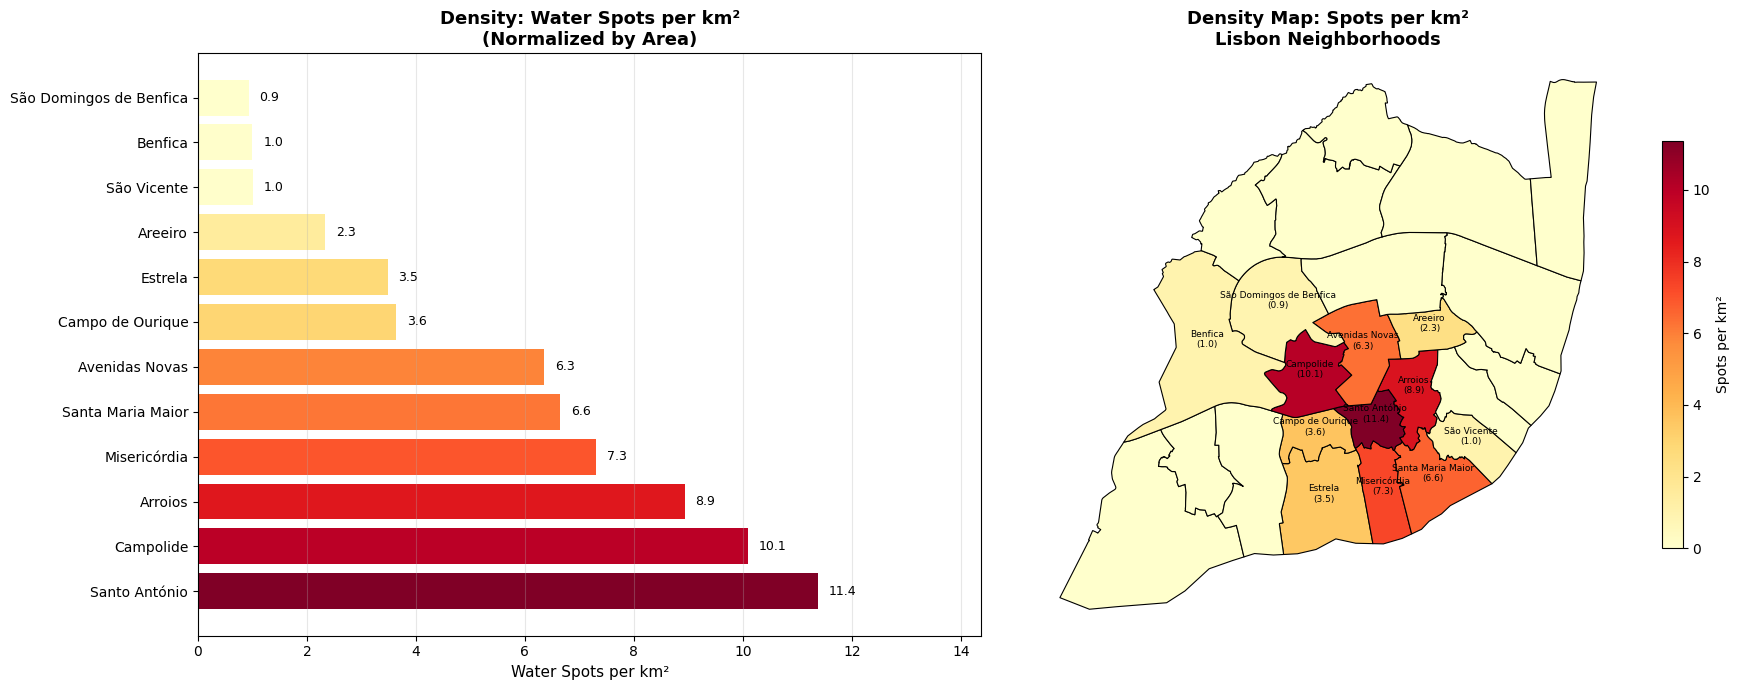

Saved: lisbon_water_density.png


In [12]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Merge counts with area data
density_df = freg_merged[freg_merged['spots'] > 0][['NOME', 'spots', 'AREA_M2']].copy()
density_df['area_km2'] = density_df['AREA_M2'] / 1_000_000
density_df['spots_per_km2'] = (density_df['spots'] / density_df['area_km2']).round(2)
density_df = density_df.sort_values('spots_per_km2', ascending=False)

print(density_df[['NOME', 'spots', 'area_km2', 'spots_per_km2']].to_string(index=False))
density_df.to_csv('density_analysis.csv', index=False)

# --- Plot: side by side raw count vs density ---
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

norm = plt.Normalize(density_df['spots_per_km2'].min(), density_df['spots_per_km2'].max())
colors = cm.YlOrRd(norm(density_df['spots_per_km2']))

# Left: density per km²
ax1 = axes[0]
bars1 = ax1.barh(density_df['NOME'], density_df['spots_per_km2'], color=colors)
ax1.set_xlabel('Water Spots per km²', fontsize=11)
ax1.set_title('Density: Water Spots per km²\n(Normalized by Area)', fontsize=13, fontweight='bold')
for bar, val in zip(bars1, density_df['spots_per_km2']):
    ax1.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}', va='center', fontsize=9)
ax1.set_xlim(0, density_df['spots_per_km2'].max() + 3)
ax1.grid(axis='x', alpha=0.3)

# Right: choropleth map colored by density
ax2 = axes[1]
freg_density = freg.merge(density_df[['NOME', 'spots_per_km2']], on='NOME', how='left')
freg_density['spots_per_km2'] = freg_density['spots_per_km2'].fillna(0)
freg_density.plot(
    column='spots_per_km2',
    cmap='YlOrRd',
    linewidth=0.8,
    edgecolor='black',
    legend=True,
    legend_kwds={'label': 'Spots per km²', 'shrink': 0.7},
    ax=ax2,
    missing_kwds={'color': 'lightgrey'}
)
for _, row in freg_density.iterrows():
    if row['spots_per_km2'] > 0:
        ax2.annotate(
            f"{row['NOME']}\n({row['spots_per_km2']:.1f})",
            xy=(row.geometry.centroid.x, row.geometry.centroid.y),
            ha='center', fontsize=6.5
        )
ax2.set_title('Density Map: Spots per km²\nLisbon Neighborhoods', fontsize=13, fontweight='bold')
ax2.axis('off')

plt.tight_layout()
plt.savefig('lisbon_water_density.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: lisbon_water_density.png")
